# Pricing Strategy Analytics: Do Discounts Increase Sales and What Discount Level Maximizes Demand?

# BUEC 420 - Data Science and Business Economics

# Author: Muhtasim Fuad Chowdhury

Retailers frequently use discounts to stimulate consumer demand. However, excessive discounting may reduce profitability or generate diminishing returns. Understanding how discount levels influence product demand is therefore important for pricing strategies in e-commerce markets.

This project investigates the relationship between product discounts and demand in an online marketplace. Specifically, it examines how discount levels, product prices, and product ratings relate to consumer demand.

The analysis uses the Kaggle Amazon Sales Dataset, which contains over 1,400 Amazon product listings along with information such as product prices, discount percentages, ratings, and review counts. Because actual sales data is not available, the number of product reviews is used as a proxy for product demand.

### The analysis proceeds through the following steps:

Step 1: Loading the dataset

Step 2: Cleaning the dataset

Step 3: Exploring the dataset

Step 4: Feature construction

Step 5: Empirical analysis

Step 6: Heterogeneous analysis

Step 7: Results interpretation



In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Step 1: Loading the Dataset

In [2]:
df = pd.read_csv("amazon.csv")

print("Shape: ", df.shape)
print("Columns: ", df.columns)
df.head()

Shape:  (1465, 16)
Columns:  Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [3]:
# For additional information on the dataset (data information and summary statistics)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B083342NKJ,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


# Step 2: Cleaning the Dataset

After loading the dataset and printing its head, it is evident that some pre-processing steps needs to be taken; the discounted_price and actual_price columns contain the currency symbols and commas with the numbers, the discount_percentage column includes the % symbol, and the rating_count column has commas. Those need to be removed. The null values from the dataset must be removed as well.

The following preprocessing steps are applied to clean the dataset.

In [4]:
# The prices in the dataset have the currency icon. That must be removed
df['discounted_price'] = (
    df['discounted_price']
    .astype(str)
    .str.replace('₹','', regex=False)
    .str.replace(',','', regex=False)
    .astype(float)
)

df['actual_price'] = (
    df['actual_price']
    .astype(str)
    .str.replace('₹','', regex=False)
    .str.replace(',','', regex=False)
    .astype(float)
)

# The discount_percentage column has %. That must be removed
df['discount'] = (
    df['discount_percentage']
    .astype(str)
    .str.replace('%','')
    .astype(float)
)

# The review counts column have ,. That must be removed
df['rating_count'] = (
    df['rating_count']
    .astype(str)
    .str.replace(',','', regex=False)
    .astype(float)
)

# rating column contains invalid values. They must be removed
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# rating_count and rating columns have null values. Dropped them
df = df.dropna(subset=['rating_count', 'rating'])

# Checks
df[['discount','actual_price','discounted_price','rating','rating_count']].describe()
# df.isnull().sum()

,discount,actual_price,discounted_price,rating,rating_count
count,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000
mean,47.672367,5453.087743,3129.981826,4.096717,18307.376881
std,21.613905,10884.467444,6950.548042,0.289497,42766.096572
min,0.000000,39.000000,39.000000,2.000000,2.000000
25%,32.000000,800.000000,325.000000,4.000000,1191.500000
50%,50.000000,1670.000000,799.000000,4.100000,5179.000000
75%,63.000000,4321.250000,1999.000000,4.300000,17342.250000
max,94.000000,139900.000000,77990.000000,5.000000,426973.000000


After applying these transformations, the dataset contains only valid numeric values for the variables used in the analysis.

The final dataset contains 1,462 products.

Onto exploring the dataset now

# Step 3: Exploring the Dataset

In this section, Exploratory Data Analysis (EDA) is performed to visualize the relationships between the key variables used in this analysis, including product ratings, discounts, prices, and demand (measured by review counts).

Text(0.5, 1.0, 'Distribution of Product Review Counts')

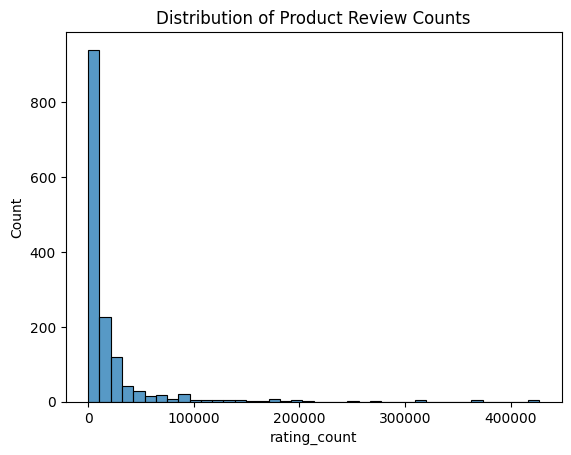

In [5]:
# Visualizing the distribution of Demand
sns.histplot(df['rating_count'], bins=40)
plt.title("Distribution of Product Review Counts")

The distribution of product review counts is highly right-skewed, indicating most products receive relatively few reviews, while a small number of products accumulate a very high number of reviews. This suggests that demand is unevenly distrubuted across products, which means log transformation must be used for the demand variable in the regression analysis.

Text(0.5, 1.0, 'Rating vs Log Demand')

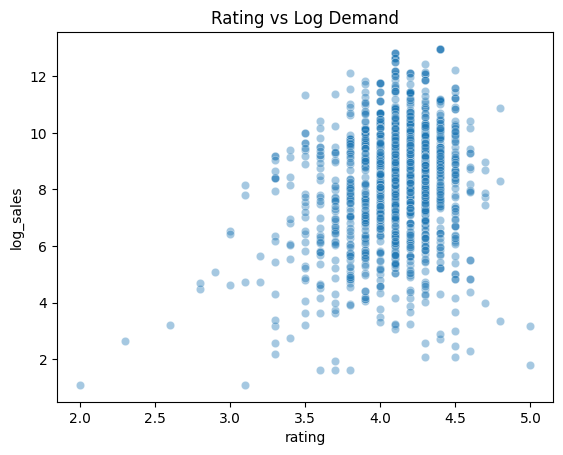

In [6]:
# log transformation on rating_count
df['log_sales'] = np.log(df['rating_count'] + 1)

# Visualizing the distribution of demand using log rating_count
sns.scatterplot(x='rating', y='log_sales', data=df, alpha=0.4)
plt.title("Rating vs Log Demand")

Now, the relationship between product rating and demand becomes easier to observe. The transformed demand variable reduces the influence of extreme values and reveals a clearer positive relationship between rating and product demand.

Text(0.5, 1.0, 'Relationship Between Product Rating and Demand')

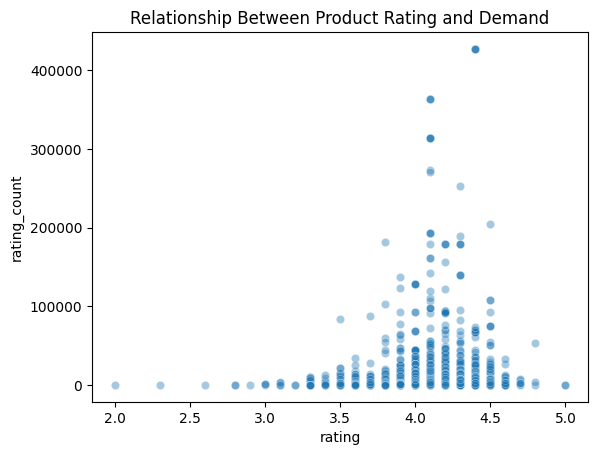

In [7]:
# Visualizing Rating vs. Demand
sns.scatterplot(x='rating', y='rating_count', data=df, alpha=0.4)
plt.title("Relationship Between Product Rating and Demand")

The Rating vs. Demand scatterplot suggests a positive relationship between product ratings and demand, which means products with higher ratings tends to have higher review counts. This indicates that percieved product quality may be associated with higher consumer purchasing decisions.

Text(0.5, 1.0, 'Relationship Between Discount Percentage and Demand')

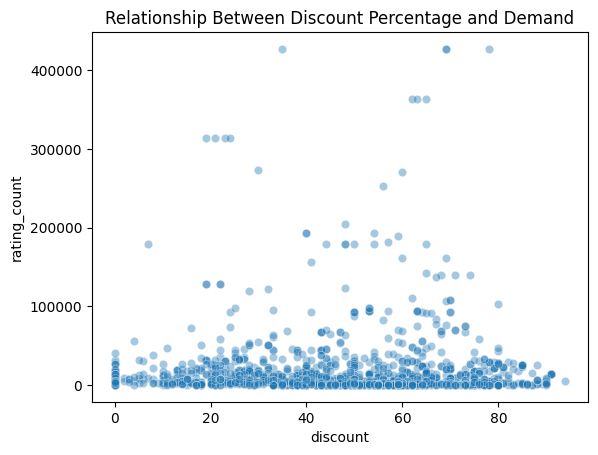

In [8]:
# Visualizing Discount vs. Demand
sns.scatterplot(x='discount', y='rating_count', data=df, alpha=0.4)
plt.title("Relationship Between Discount Percentage and Demand")

The Discount Pecentage vs. Demand scatterplot suggests a weak relationship between discount percentage and demand, which means discounts alone may not strongly determine product demand as high-demand products exist across a wide range of discount levels.

Text(0.5, 1.0, 'Relationship Between Price and Demand')

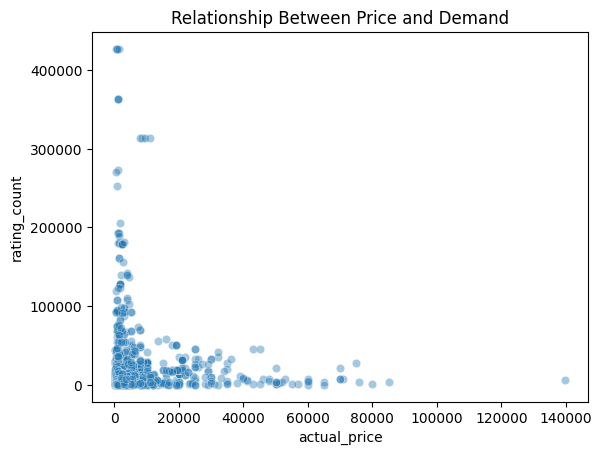

In [9]:
# Visualizing Price vs. Demand
sns.scatterplot(x='actual_price', y='rating_count', data=df, alpha=0.4)
plt.title("Relationship Between Price and Demand")

The Price vs. Demand scatterplot suggests a negative relationship between price and demand, which means high-priced products tend to receive fewer reviews. This makes it difficult to identify a strong linear relationship between price and demand.

I am also going to create a correlation heatmap to highlight the relationships between the key variables in the dataset.

<Axes: >

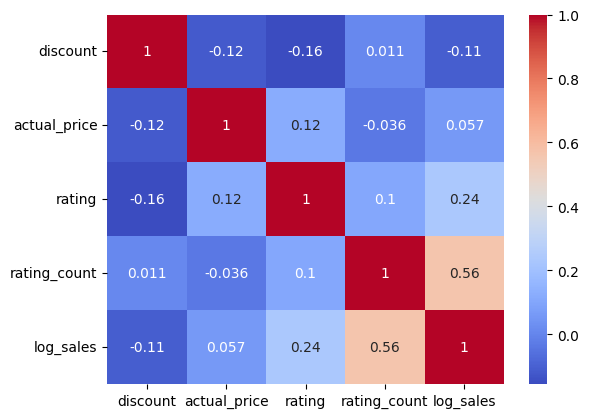

In [10]:
sns.heatmap(
    df[['discount','actual_price','rating','rating_count','log_sales']].corr(),
    annot=True,
    cmap='coolwarm'
)

The correlation heatmap shows a moderate positive correlation between product review counts and log demand. Product ratings also display a weak positive relationship with demand, suggesting that higher-rated products tend to receive more reviews. Discount percentage and price exhibit weak correlations with demand, indicating that these factors alone are unlikely to strongly determine product demand.

# Step 4: Feature Construction



In this section, some additional variables are going to be constructed to improve the empirical analysis by normalizing skewed variables, capture nonlinear effects, and prepare the dataset for regression analysis.

In [15]:
# Just like sales, price is right-skewed. So transformed using log
df['log_price'] = np.log(df['actual_price'] + 1)

# Create column to demonstrate rating high (1) if greater than or equal to 4.5, not high (0) otherwise
df['high_rating'] = (df['rating'] >= 4.5).astype(int)

# Create column to demonstrate high discount (1) if greater than or equal to 50, not high (0) otherwise
df['high_discount'] = (df['discount'] >= 50).astype(int)

# Create column to demonstrate expensive product (1) if greater than median of actual price, not high (0) otherwise
df['expensive_product'] = (df['actual_price'] > df['actual_price'].median()).astype(int)

# To capture if highly rated products benefit more from discounts
df['rating_discount_interaction'] = df['rating'] * df['discount']

# Check
df[['actual_price','log_price','rating','high_rating','discount','high_discount']].head()

,actual_price,log_price,rating,high_rating,discount,high_discount
0,1099.0,7.003065,4.2,0,64.0,1
1,349.0,5.857933,4.0,0,43.0,0
2,1899.0,7.549609,3.9,0,90.0,1
3,699.0,6.551080,4.2,0,53.0,1
4,399.0,5.991465,4.2,0,61.0,1


# Step 5: Empirical Analysis

It is now time to estimate the relationship between discounts and product demand using regression analysis.

This analysis will tell us how discount levels influence product demand while controlling for price and product ratings.

The dependant variable is the log-transformed review count, which serves as a proxy for product demand.

In [16]:
# Baseline Model
X = df[['discount', 'log_price', 'rating']]
X = sm.add_constant(X)

y = df['log_sales']

model1 = sm.OLS(y, X).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     33.95
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           3.31e-21
Time:                        15:53:50   Log-Likelihood:                -3058.2
No. Observations:                1462   AIC:                             6124.
Df Residuals:                    1458   BIC:                             6146.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5001      0.803      1.868      0.0

It seems discounts have a statistically significant but very small negative effect, while ratings matter most for demand. Price effect is weak on demand. The model explains only a modest share of the variation in product demand (R^2 = 0.065), suggesting that other unobserved factors likely influence demand. This means higher product ratings are strongly associated with higher demand.

Next step is including the interaction term

In [17]:
# Interaction Model
X = df[['discount', 'log_price', 'rating', 'rating_discount_interaction']]
X = sm.add_constant(X)

y = df['log_sales']

model2 = sm.OLS(y, X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     25.45
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           2.07e-20
Time:                        15:56:30   Log-Likelihood:                -3058.2
No. Observations:                1462   AIC:                             6126.
Df Residuals:                    1457   BIC:                             6153.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

With the interaction model, the discount coefficient becomes insignificant, and the interaction term also becomes insignificant, while rating’s significance remains strong. This suggests highly rated products do not appear to benefit more from discounts; overall, discounts do not meaningfully influence demand in this dataset.

Next, to answer what discount level maximizes demand, non-linear discount effects are analyzed. A squared discount term is added to the baseline model to capture potential diminishing returns to discounting.

In [21]:
# Nonlinear Model

# Squaring discount
df['discount_sq'] = df['discount']**2

# Regression
X = df[['discount','discount_sq','log_price','rating']]
X = sm.add_constant(X)

y = df['log_sales']

model3 = sm.OLS(y, X).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     26.17
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           5.57e-21
Time:                        16:38:18   Log-Likelihood:                -3056.8
No. Observations:                1462   AIC:                             6124.
Df Residuals:                    1457   BIC:                             6150.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.6809      0.810      2.075      

In [22]:
beta1 = model3.params['discount']
beta2 = model3.params['discount_sq']

optimal_discount = -beta1 / (2 * beta2)
print(optimal_discount)

65.50463657791136


The results suggest a weak non-linear relationship between discounts and demand. Using the estimated coefficients, the turning point of the quadratic discount function is calculated as approximately 65.5%. Because the squared discount coefficient is positive, this turning point represents a minimum rather than a maximum level of predicted demand. This indicates that demand initially declines as discounts increase, reaching its lowest level around 65%, before slightly increasing again at very high discount levels. However, the squared discount term is only marginally significant, suggesting that the evidence for a strong non-linear discount effect in this dataset is limited.

Now, to visualize how predicted demand changes across different discount levels:

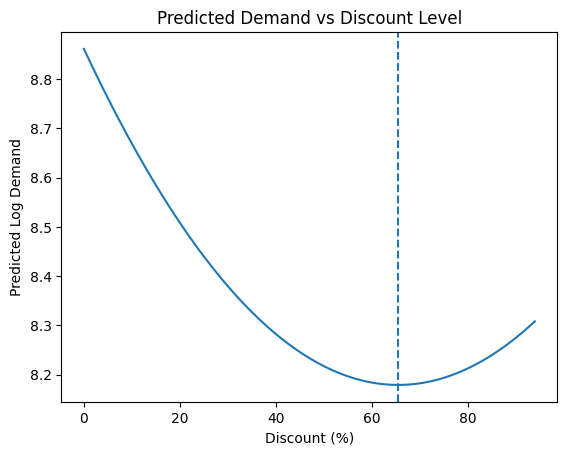

In [27]:
# Creating range of discount values from min to max observed in the dataset
discount_range = np.linspace(df['discount'].min(), df['discount'].max(), 100)

# Extract the estimated regression coefficients
beta0 = model3.params['const']
beta1 = model3.params['discount']
beta2 = model3.params['discount_sq']
beta3 = model3.params['log_price']
beta4 = model3.params['rating']

# Use average values for price and rating to isolate effect of demand
mean_price = df['log_price'].mean()
mean_rating = df['rating'].mean()

# Creating predicted log demand for each discount level
predicted_log_sales = (
    beta0
    + beta1 * discount_range
    + beta2 * discount_range**2
    + beta3 * mean_price
    + beta4 * mean_rating
)

# Plot
plt.plot(discount_range, predicted_log_sales)
plt.axvline(optimal_discount, linestyle='--')
plt.xlabel("Discount (%)")
plt.ylabel("Predicted Log Demand")
plt.title("Predicted Demand vs Discount Level")
plt.show()

As visualized, predicted demand declines as discount levels increase, reaching its lowest point around 65%, before slightly increasing again. This reflects the weak non-linear relationship between discounts and demand captured by the regression model.

# Step 6: Heterogenous Analysis

Now, some analysis will be done to test if discounts affect different types of products differently as even though the overall discount effect was weak, it might still matter for specific product segments.

First thing I would like to test out: do highly rated products respond differently to discounts?

In [23]:
# Interaction between discount and high rating
df['discount_high_rating'] = df['discount'] * df['high_rating']

X = df[['discount','log_price','rating','high_rating','discount_high_rating']]
X = sm.add_constant(X)

y = df['log_sales']

model4 = sm.OLS(y, X).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     31.73
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           9.30e-31
Time:                        16:42:52   Log-Likelihood:                -3031.9
No. Observations:                1462   AIC:                             6076.
Df Residuals:                    1456   BIC:                             6108.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.8867 

To explore whether highly rated products respond differently to discounts, an interaction term between discount and the high_rating indicator was introduced. The results show that the interaction term is statistically significant and negative. This indicates that discounts have a stronger negative effect on demand for highly rated products compared to lower-rated products.

From the regression results, the discount coefficient is −0.0042, while the interaction term coefficient is −0.0243. This means the total discount effect for highly rated products is approximately:

                                          -0.0042 + (-0.0243) = -0.0285

This suggests that discounts reduce demand more strongly for highly rated products than for lower-rated ones. One possible explanation is that highly rated products rely more on perceived quality and reputation, so heavy discounting may reduce their perceived value. The model’s explanatory power also improves (R² ≈ 0.098), indicating that accounting for product heterogeneity helps better explain variation in product demand.

Another thing I would like to test out: do expensive products benefit more from discounts?

In [24]:
# Interaction between discount and expensive product
df['discount_expensive'] = df['discount'] * df['expensive_product']

X = df[['discount','log_price','rating','expensive_product','discount_expensive']]
X = sm.add_constant(X)

y = df['log_sales']

model5 = sm.OLS(y, X).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     20.53
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           7.37e-20
Time:                        16:44:28   Log-Likelihood:                -3057.7
No. Observations:                1462   AIC:                             6127.
Df Residuals:                    1456   BIC:                             6159.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.4002      0

To explore whether expensive products respond differently to discounts, an interaction term between discount and the expensive_product indicator was introduced. The results show that the interaction term is not statistically significant, suggesting that expensive products do not benefit more from discounts compared to cheaper products.

From the regression results, the discount coefficient is −0.0085, while the interaction term coefficient is 0.0039. This implies that the total discount effect for expensive products is approximately:

                                              -0.0085 + 0.0039 = -0.0046
This suggests that discounts still have a small negative effect on demand for expensive products, although the effect is slightly smaller than for cheaper products. However, since the interaction term is not statistically significant, there is no strong evidence that discount effectiveness differs between expensive and cheaper products. The model’s explanatory power remains similar to the previous models (R² ≈ 0.066), indicating that this form of product heterogeneity does not substantially improve the explanation of demand variation.

# Conclusion

This analysis examined how discount levels influence product demand in an e-commerce marketplace using regression-based empirical methods. The baseline regression results suggest that discounts have a statistically significant but very small effect on demand, while product ratings are the strongest predictor of demand across all models. Price effects appear relatively weak, indicating that perceived product quality plays a larger role than pricing strategies in driving demand within this dataset.

To explore potential non-linear effects, a quadratic discount term was introduced. The results suggest a weak non-linear relationship between discounts and demand. The estimated turning point occurs at approximately 65.5% discount, where predicted demand reaches its lowest level before increasing slightly again at extremely high discount levels. However, the squared discount term is only marginally significant, indicating limited evidence for strong non-linear discount effects.

Heterogeneous analysis further examined whether discount effectiveness varies across different types of products. The results show that highly rated products respond differently to discounts, with discounts having a stronger negative effect on demand for products with high ratings. This suggests that highly rated products may rely more on perceived quality and reputation, and heavy discounting could reduce their perceived value. In contrast, no strong evidence was found that expensive products benefit more from discounts compared to cheaper products.

Overall, the findings suggest that discount strategies alone may not significantly increase demand in this dataset, and that product quality, as reflected by ratings, plays a more important role in determining product demand. These results highlight the importance of considering product characteristics when designing pricing and promotional strategies.